In [1]:
!pip install torch torchvision wandb pytorch-lightning torchmetrics matplotlib pillow numpy lightning


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 15.1 MB/s eta 0:00:00a 0:00:01


### author:  https://github.com/DevSenpai01
https://github.com/DevSenpai01/voc_semantic_segmentation_unet_convtranspose/blob/main/VOC_Semantic_Segmentation.ipynb

In [2]:
import wandb

# this will open an input cell asking you to paste your API key
wandb.login(key="", relogin=True)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: a-s-kurdyubov (a-s-kurdyubov-spbu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].


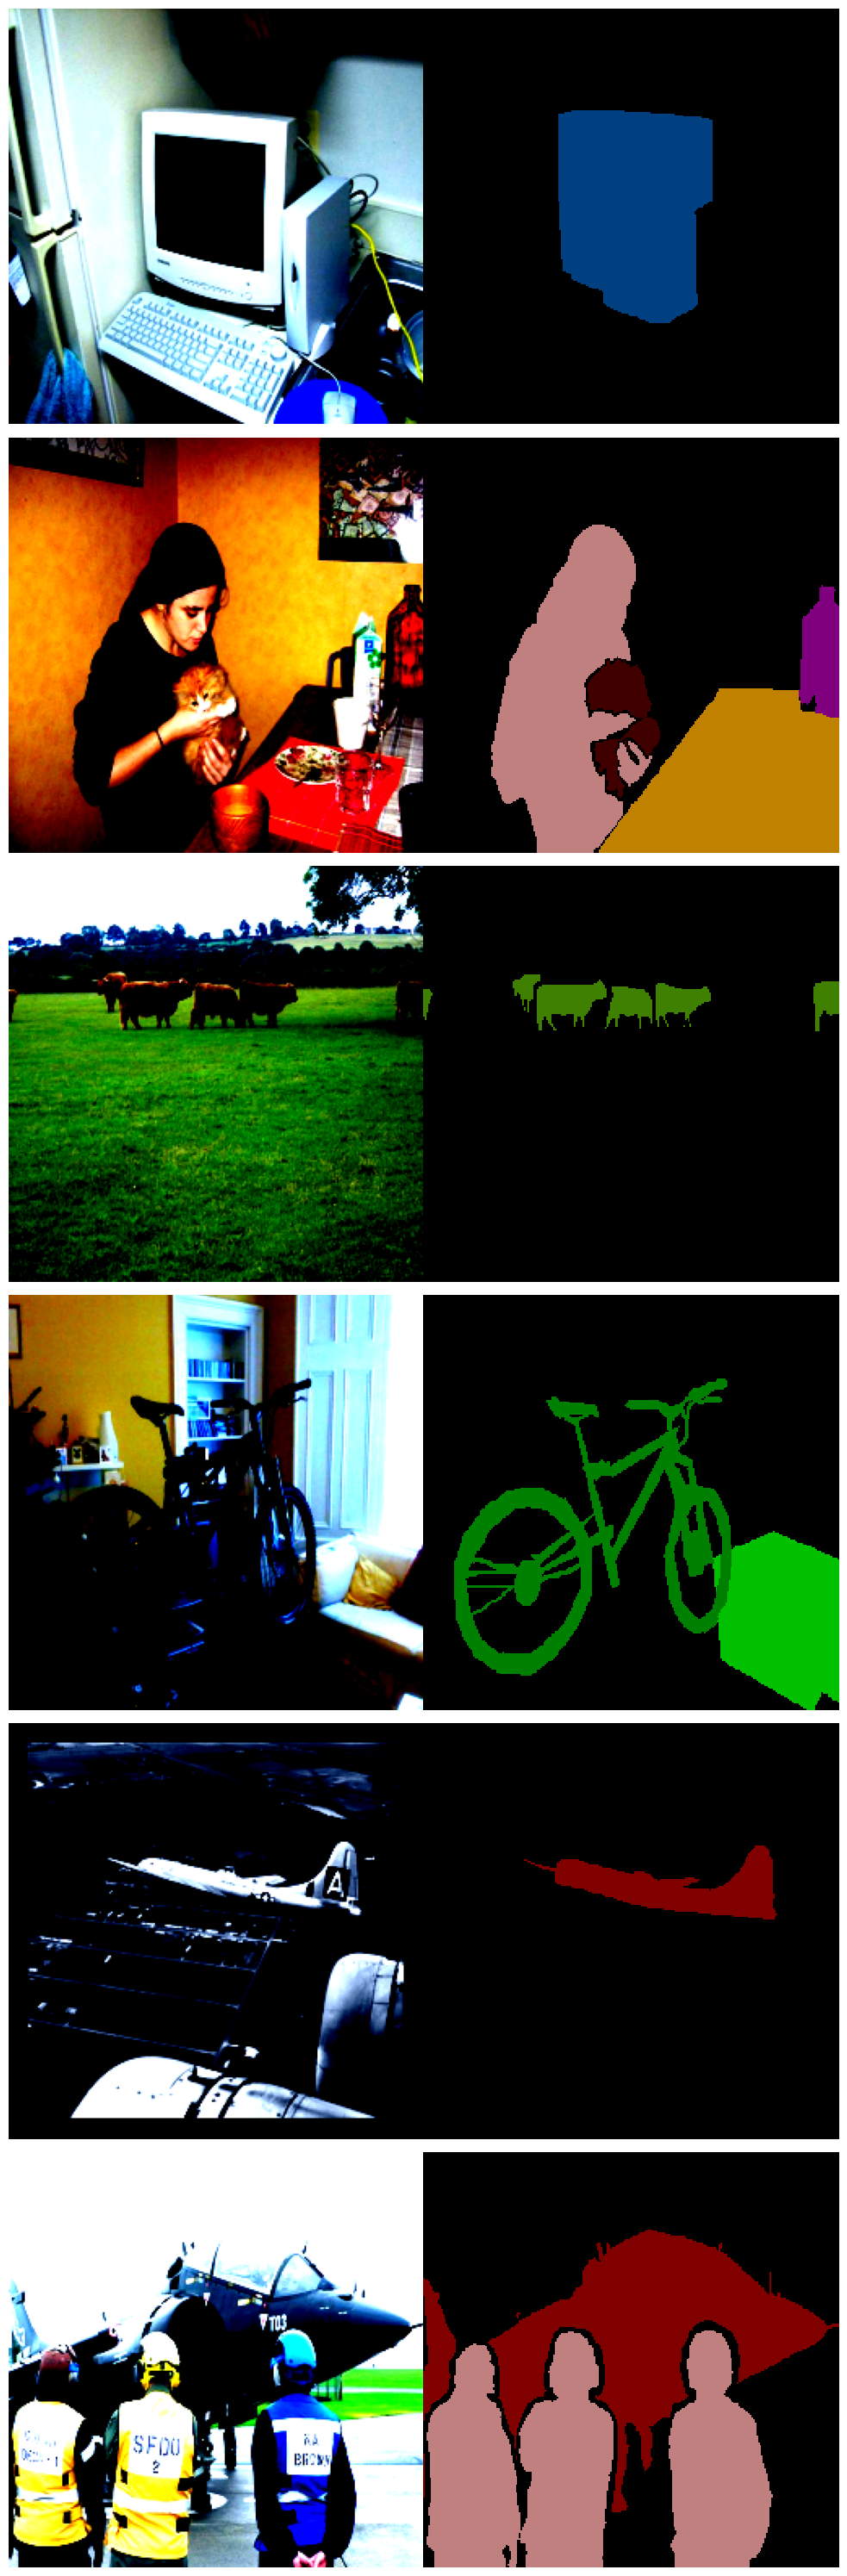

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
       BatchNorm2d-2         [-1, 64, 256, 256]             128
            Conv2d-3        [-1, 128, 128, 128]          73,856
       BatchNorm2d-4        [-1, 128, 128, 128]             256
            Conv2d-5          [-1, 192, 64, 64]         221,376
       BatchNorm2d-6          [-1, 192, 64, 64]             384
   ConvTranspose2d-7        [-1, 192, 128, 128]         147,648
            Conv2d-8        [-1, 128, 128, 128]         368,768
       BatchNorm2d-9        [-1, 128, 128, 128]             256
  ConvTranspose2d-10        [-1, 128, 256, 256]          65,664
           Conv2d-11         [-1, 64, 256, 256]         110,656
      BatchNorm2d-12         [-1, 64, 256, 256]             128
           Conv2d-13         [-1, 21, 256, 256]           1,365
Total params: 992,277
Trainable params:

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
│ 1  │ encoder1   │ Conv2d           │  1.8 K │ train │     0 │
│ 2  │ encoder2   │ Conv2d           │ 73.9 K │ train │     0 │
│ 3  │ bottleneck │ Conv2d           │  221 K │ train │     0 │
│ 4  │ upconv1    │ ConvTranspose2d  │  147 K │ train │     0 │
│ 5  │ decoder2   │ Conv2d           │  368 K │ train │     0 │
│ 6  │ upconv2    │ ConvTranspose2d  │ 65.7 K │ train │     0 │
│ 7  │ decoder1   │ Conv2d           │  110 K │ train │     0 │
│ 8  │ outconv    │ Conv2d           │  1.4 K │ train │     0 │
│ 9  │ bn1        │ BatchNorm2d      │    128 │ train │     0 │
│ 10 │ bn2        │ BatchNorm2d      │    256 │ train │     0 │
│ 11 │ bn3        │ BatchNorm2d      │    384 │ train │     0 │
└────┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 991 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 991 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got 
range [-2.117904..2.64].

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got 
range [-2.117904..2.622571].

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got 
range [-2.1007793..2.3262744].

`Trainer.fit` stopped: `max_epochs=50` reached.


→ trainer.fit returned


In [3]:
import os
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import Resize
import torch.nn.functional as F
from matplotlib.colors import ListedColormap
import torch.optim as optim
import lightning as pl

import wandb
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint
import torchmetrics
from torchsummary import summary

import os
# os.environ["WANDB_API_KEY"] = ""


wandb_logger = WandbLogger(log_model="all", project="VOCSegmentation", name='exp2_convtranspose')
# Check if CUDA is available and choose the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#dataset link : https://www.kaggle.com/datasets/sovitrath/voc-2012-segmentation-data
ALL_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 
    'chair', 'cow', 'dining table', 'dog', 'horse', 'motorbike', 'person', 'potted plant', 
    'sheep', 'sofa', 'train', 'tv/monitor'
]

LABEL_COLORS_LIST = [
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128], [128, 0, 128],
    [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
    [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128], [0, 64, 0], [128, 64, 0],
    [0, 192, 0], [128, 192, 0], [0, 64, 128]
]
jaccard = torchmetrics.JaccardIndex(task="multiclass", num_classes=len(ALL_CLASSES)).to(device)

# Normalize colors to range [0, 1]
normalized_colors = [[r/255, g/255, b/255] for r, g, b in LABEL_COLORS_LIST]

# Create colormap
cmap = ListedColormap(normalized_colors)

class VOCDataSet(Dataset):
    def __init__(self, root_dir, dataset_type='train', transform=None):
        self.root_dir = root_dir
        self.transform = transform

        if dataset_type == 'train':
            self.image_folder = os.path.join(root_dir, 'train_images')
            self.label_folder = os.path.join(root_dir, 'train_labels')
        elif dataset_type == 'val':
            self.image_folder = os.path.join(root_dir, 'valid_images')
            self.label_folder = os.path.join(root_dir, 'valid_labels')
        else:
            raise ValueError("Invalid dataset_type. Use 'train' or 'val'.")

        self.image_list = os.listdir(self.image_folder)
        self.label_list = os.listdir(self.label_folder)
        self.image_list = sorted(self.image_list)[:100]
        self.label_list = sorted(self.label_list)[:100]

    # Convert RGB label to an integer label
    def rgb_to_integer(self,label_rgb):
        label_integer = np.zeros(label_rgb.shape[:2], dtype=np.uint8)
        for i, color in enumerate(LABEL_COLORS_LIST):
            mask = np.all(label_rgb == color, axis=-1)
            label_integer[mask] = i
        return label_integer

    def __len__(self):
        return len(self.image_list)

    #read image and mask for a single image and apply transform 
    #be careful with applying transformations on the Mask (it should remain integer)
    def __getitem__(self, idx):
        img_name = os.path.join(self.image_folder, self.image_list[idx])
        label_name = os.path.join(self.label_folder, self.label_list[idx])
        image = Image.open(img_name)
        label = Image.open(label_name).convert('RGB')      
        label_array = np.array(label)
        label_integer = self.rgb_to_integer(label_array)      
        
        if self.transform:
            image = self.transform(image)         
            
        imSize = self.transform.transforms[0].size[0]
        label_integer = (torch.tensor(label_integer).unsqueeze(0)).unsqueeze(0)
        label_integer = F.interpolate(label_integer, size=(imSize, imSize), mode='nearest').squeeze(0).squeeze(0).long() #only use NN
               
        return image, label_integer


# Define the transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATA_ROOT = '/kaggle/input/datasets/sovitrath/voc-2012-segmentation-data/voc_2012_segmentation_data'

# Create a train dataset object
train_dataset = VOCDataSet(root_dir=DATA_ROOT, dataset_type='train', transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Create a validation dataset object
val_dataset = VOCDataSet(root_dir=DATA_ROOT, dataset_type='val',   transform=transform)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)




# Get a batch of data & display it (just to see we correctly read the dataset!)
images, masks = next(iter(train_loader))
# Display the batch
fig, axs = plt.subplots(6, 2, figsize=(10, 30))
for i in range(6):
    # Display image
    axs[i, 0].imshow(images[i].permute(1, 2, 0))
    axs[i, 0].axis('off')    
    #use NN to display exact
    axs[i, 1].imshow(np.squeeze(masks[i]), cmap=cmap, interpolation='nearest', vmin=0, vmax=len(ALL_CLASSES)-1)
    axs[i, 1].axis('off')
plt.tight_layout()
plt.show(block=True)


#Custom UNET Model Class with ConvTranspose2d
class VOCUNet(pl.LightningModule):
    def __init__(self, in_channels=3, n_classes=21, features=64, learning_rate=1e-3):
        super(VOCUNet, self).__init__()
        self.learning_rate = learning_rate
        self.criterion = nn.CrossEntropyLoss()      

        # Encoder Path
        self.encoder1 = nn.Conv2d(in_channels, features, kernel_size=3, padding=1)
        self.encoder2 = nn.Conv2d(features, features*2, kernel_size=3, padding=1)
        
        # Bottleneck
        self.bottleneck = nn.Conv2d(features*2, features*3, kernel_size=3, padding=1)
        
        # Decoder Path with ConvTranspose2d instead of Upsample
        self.upconv1 = nn.ConvTranspose2d(features*3, features*3, kernel_size=2, stride=2)
        self.decoder2 = nn.Conv2d(features*3+features*2, features*2, kernel_size=3, padding=1)
        
        self.upconv2 = nn.ConvTranspose2d(features*2, features*2, kernel_size=2, stride=2)
        self.decoder1 = nn.Conv2d(features*2+features, features, kernel_size=3, padding=1)
        
        self.outconv = nn.Conv2d(features, n_classes, kernel_size=1)

        # Batch Normalization layers
        self.bn1 = nn.BatchNorm2d(features)
        self.bn2 = nn.BatchNorm2d(features*2)
        self.bn3 = nn.BatchNorm2d(features*3)

    def forward(self, x):        
        # Encoder Path
        x1 = self.encoder1(x)  
        x1 = self.bn1(x1)      
        x1 = nn.ReLU()(x1)
        
        x = nn.MaxPool2d(2, stride=2)(x1)
        x2 = self.encoder2(x)  
        x2 = self.bn2(x2)            
        x2 = nn.ReLU()(x2)

        # Bottleneck
        x = nn.MaxPool2d(2, stride=2)(x2)  
        x = self.bottleneck(x)
        x = self.bn3(x)              
        x = nn.ReLU()(x)

        # Decoder Path with ConvTranspose2d
        x = self.upconv1(x)  # Replace nn.Upsample with ConvTranspose2d
        x = torch.cat([x, x2], dim=1)
        x = self.decoder2(x)
        x = self.bn2(x)
        x = nn.ReLU()(x)

        x = self.upconv2(x)  # Replace nn.Upsample with ConvTranspose2d
        x = torch.cat([x, x1], dim=1)
        x = self.decoder1(x)
        x = self.bn1(x)
        x = nn.ReLU()(x)

        y = self.outconv(x)

        return y
        
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        softmaxed_logits = torch.softmax(logits, dim=1)  # Apply softmax along the class dimension
        # Get the integer mask by taking the argmax along the class dimension
        predicted_mask = torch.argmax(softmaxed_logits, dim=1)

        iou = jaccard(predicted_mask, y)
        self.log('train/loss', loss, on_epoch=True, on_step=True, prog_bar=True)
        self.log('train/iou', iou, on_epoch=True, on_step=True, prog_bar=True)

        if(batch_idx == 0):
            # Display the batch
            fig, axs = plt.subplots(6, 3, figsize=(10, 30))
            for i in range(6):
                # Display image
                axs[i, 0].imshow(x[i].cpu().detach().permute(1, 2, 0), vmin=torch.min(x[i]), vmax=torch.max(x[i]))
                axs[i, 0].axis('off')
                # Display mask    
                # use NN to display exact
                axs[i, 1].imshow(y[i].cpu().detach(), cmap=cmap, interpolation='nearest', vmin=0, vmax=len(ALL_CLASSES)-1)
                axs[i, 1].axis('off')

                axs[i, 2].imshow(predicted_mask[i].cpu().detach(), cmap=cmap, interpolation='nearest', vmin=0, vmax=len(ALL_CLASSES)-1)
                axs[i, 2].axis('off')               
            plt.tight_layout()          
            fig = plt.gcf()
            fig.canvas.draw()
            # data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
            # data = data.reshape(fig.canvas.get_width_height()[::-1] + (3,))
            plt.close()
            # Log images
            # wandb_logger.log_image(key="Train_Images", images=[data], caption=[f"Image-{self.trainer.current_epoch}"])

        return loss
        
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        softmaxed_logits = torch.softmax(logits, dim=1)  # Apply softmax along the class dimension
        # Get the integer mask by taking the argmax along the class dimension
        predicted_mask = torch.argmax(softmaxed_logits, dim=1)

        iou = jaccard(predicted_mask, y)
        self.log('val/loss', loss, on_epoch=True, on_step=True, prog_bar=True)
        self.log('val/iou', iou, on_epoch=True, on_step=True, prog_bar=True)

        if(batch_idx == 0):
            # Display the batch
            fig, axs = plt.subplots(6, 3, figsize=(10, 30))
            for i in range(6):
                # Display image
                axs[i, 0].imshow(x[i].cpu().detach().permute(1, 2, 0), vmin=torch.min(x[i]), vmax=torch.max(x[i]))
                axs[i, 0].axis('off')
                # Display mask    
                # use NN to display exact
                axs[i, 1].imshow(y[i].cpu().detach(), cmap=cmap, interpolation='nearest', vmin=0, vmax=len(ALL_CLASSES)-1)
                axs[i, 1].axis('off')

                axs[i, 2].imshow(predicted_mask[i].cpu().detach(), cmap=cmap, interpolation='nearest', vmin=0, vmax=len(ALL_CLASSES)-1)
                axs[i, 2].axis('off')               
            plt.tight_layout()
            
            fig = plt.gcf()
            fig.canvas.draw()
            # data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
            # data = data.reshape(fig.canvas.get_width_height()[::-1] + (3,))

            plt.close()

            # Log images
            # wandb_logger.log_image(key="Val_Images", images=[data], caption=[f"Image-{self.trainer.current_epoch}"])
                  
        return loss
        
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5) #, verbose=True)
        return {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "val/iou"}

    def configure_callbacks(self):
        """Configures the ModelCheckpoint callback."""
        checkpoint_callback = ModelCheckpoint(
            monitor='val/iou',  # Monitor validation IoU
            dirpath='./checkpoints',  # Directory to save checkpoints
            filename='convtranspose_model-{epoch:02d}-{val/iou:.4f}',  # Filename pattern
            save_top_k=3,  # Save the top 3 models
            mode='max',  # Save model with highest IoU
            # verbose=True
        )
        return [checkpoint_callback]  # Return a list of callbacks
    

# Train the model
model = VOCUNet().to(device)
summary(model, (3, 256, 256))

callbacks = model.configure_callbacks()


trainer = pl.Trainer(
    logger=wandb_logger,
    max_epochs=50,
    devices=1,
    accelerator="auto",
    callbacks=callbacks,
    log_every_n_steps=10
)
print("→ Starting trainer.fit…")
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("→ trainer.fit returned")




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.2317834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].


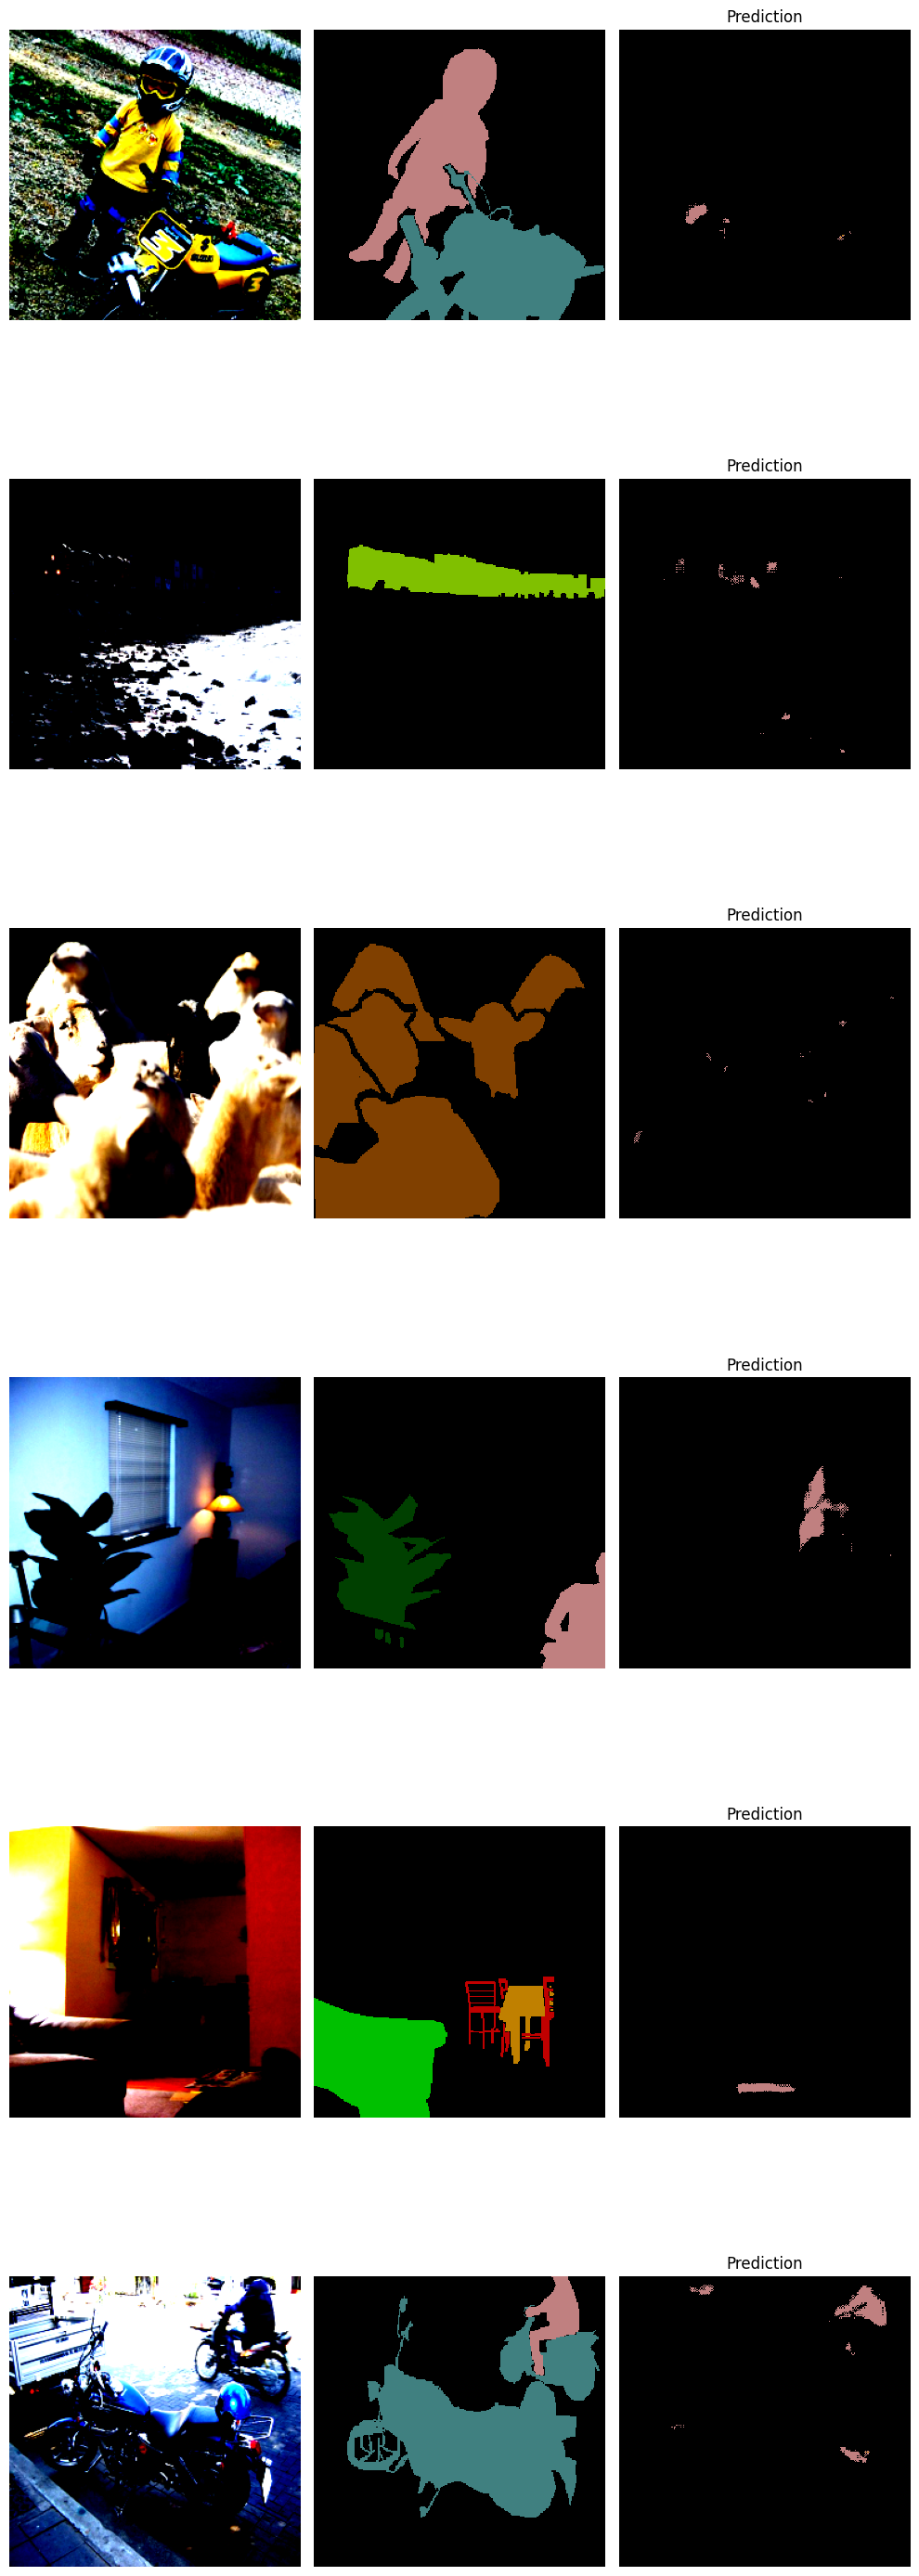

In [9]:
images, masks = next(iter(train_loader))
# Display the batch
fig, axs = plt.subplots(6, 3, figsize=(10, 30))
for i in range(6):
    # Display image
    axs[i, 0].imshow(images[i].permute(1, 2, 0))
    axs[i, 0].axis('off')    
    #use NN to display exact
    axs[i, 1].imshow(np.squeeze(masks[i]), cmap=cmap, interpolation='nearest', vmin=0, vmax=len(ALL_CLASSES)-1)
    axs[i, 1].axis('off')

    # images[i] имеет размерность [3, 256, 256]
    # Добавляем batch dimension: [1, 3, 256, 256]
    input_image = images[i].unsqueeze(0)  # или images[i].reshape(1, 3, 256, 256)
    
    # Получаем предсказание
    pred_output = model(input_image)  # [1, 21, 256, 256]
    
    # Применяем softmax и получаем маску класса
    pred_mask = torch.softmax(pred_output, dim=1)  # [1, 21, 256, 256]
    pred_mask = torch.argmax(pred_mask, dim=1)     # [1, 256, 256]
    
    # Убираем размерность батча для визуализации
    pred_mask = pred_mask.squeeze(0)  # [256, 256]
    
    # Отображаем предсказание
    axs[i, 2].imshow(pred_mask.cpu().detach(), cmap=cmap, interpolation='nearest',
                     vmin=0, vmax=len(ALL_CLASSES)-1)
    axs[i, 2].set_title('Prediction')
    axs[i, 2].axis('off')


plt.tight_layout()
plt.show(block=True)

In [10]:
torch.save(model.state_dict(), "model_VOC_Semantic_Segmentation_by.pt")